# Code to Visualize Features Distributions 

In [1]:
import sys
sys.path.append("../")
import warnings
from py_code import config_loader 
from py_code import initialize_df
import numpy as np
warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
from matplotlib.ticker import LogLocator, NullFormatter


In [2]:
conf = config_loader.load_config("../gamma_hadron_discrimination/config.yaml")

DAT_path_protons = conf["DAT_path_protons"]
DAT_path_gammas = conf["DAT_path_gammas"]

TRAIN_DAT_MIN = conf["TRAIN_DAT_MIN"]
TRAIN_DAT_MAX = conf["TRAIN_DAT_MAX"]

TEST_PROTONS_DAT_MIN = conf["TEST_PROTONS_DAT_MIN"]
TEST_PROTONS_DAT_MAX = conf["TEST_PROTONS_DAT_MAX"]

TEST_GAMMAS_DAT_MIN = conf["TEST_GAMMAS_DAT_MIN"]
TEST_GAMMAS_DAT_MAX = conf["TEST_GAMMAS_DAT_MAX"]

traces_dir = conf["traces_dir"]
feats_dir =  conf["feats_dir"]
output_dir = conf["output_dir"]
models_dir = conf["models_dir"]
results_dir = conf["results_dir"]
pictures_dir = conf["pictures_dir"]

params_dir = conf["params_dir"]
cut_dir = conf["cut_dir"]
ADC_dir = conf["ADC_dir"]
array_dir = conf["array_dir"]

features_cut_dir = conf["features_cut_dir"]
training_selection_dir = conf["training_selection_dir"]
testing_selection_dir = conf["testing_selection_dir"]

tank_type = conf["tank_type"]
FF = conf["FF"]
time_window = conf["time_window"]
min_energy_reco = conf["min_energy_reco"]
max_energy_reco = conf["max_energy_reco"]
min_theta = conf["min_theta"]
max_theta = conf["max_theta"]
intended_cut_on_pes = conf["intended_cut_on_pes"]
mpmt_or_8inches = conf["mpmt_or_8inches"]
ADC_MHz = conf["ADC_MHz"]
ML_model = conf["ML_model"]

train_min_st_dist = conf["train_min_st_dist"]
train_max_st_dist = conf["train_max_st_dist"]
train_pe_min = conf["train_pe_min"]

test_min_st_dist = conf["test_min_st_dist"]
test_max_st_dist = conf["test_max_st_dist"]
test_pe_min = conf["test_pe_min"]

In [3]:
PROJECT_DIR = Path.cwd().parent

pictures_save_dir = Path(f"{PROJECT_DIR}/{pictures_dir}/{array_dir}/{params_dir}/{training_selection_dir}/{testing_selection_dir}/") 
pictures_save_dir.mkdir(parents=True, exist_ok = True)

In [4]:
path = Path(f"{PROJECT_DIR}/{feats_dir}/{array_dir}/train/sm_bkg/{params_dir}/{features_cut_dir}/df_{mpmt_or_8inches}_{ADC_dir}_{intended_cut_on_pes}bkg{intended_cut_on_pes}smu_pe.parquet")

In [5]:
ADC_MHz = None
pe_min = 13  
pe_max = np.inf

df = pd.read_parquet(path)

df_sm = df[df["IsThereMuon"] == 1]
df_eg = df[df["IsThereMuon"] == 0]

print(*df.columns, sep="\n")

t0
tref
t60
t120
t180
t240
t300
X_T
Y_T
R_T
Nom_En
Nom_Th
Nom_X_C
Nom_Y_C
T_C
IsThereMuon
t_ref0
t_ref60
t_ref120
t_ref180
t_ref240
t_ref300
multiplicity
total_pe
a_time_2ch
a_time_6ch
t_min
t_2min
t_3min
t_4min
t_5min
t_6min
t_7min
D_t
ch0_pe
chref_pe
ch60_pe
ch120_pe
ch180_pe
ch240_pe
ch300_pe
norm_ch0_pe
norm_chref_pe
norm_ch60_pe
norm_ch120_pe
norm_ch180_pe
norm_ch240_pe
norm_ch300_pe
var
r_bar
a_6ch
a_4ch
a_2ch
a_dyn


Number of single-muon events = 67014
Number of gamma/e± events = 379497
Single-muon mean = 0.702
Single-muon standard deviation = 0.215
Gamma/e± mean = 0.405
Gamma/e± standard deviation = 0.286
Overlap = 0.537
Total variation distance = 0.463


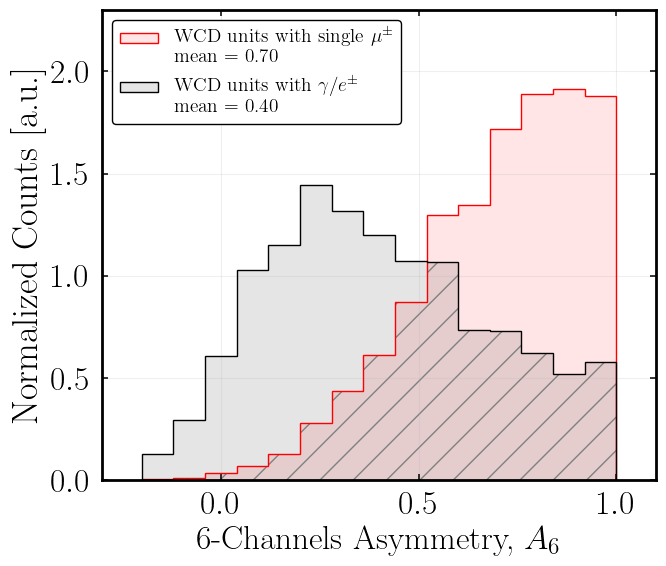

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


class OffsetHandler(HandlerBase):

    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        patch = Rectangle((0, 0), width, height, facecolor=orig_handle.get_facecolor(), edgecolor=orig_handle.get_edgecolor(), linewidth=orig_handle.get_linewidth())
        offset_transform = trans + mtransforms.Affine2D().translate(self.x_offset, self.y_offset)
        patch.set_transform(offset_transform)
        return [patch]


sm_a6 = df_sm["a_6ch"].dropna()
eg_a6 = df_eg["a_6ch"].dropna()

print("Number of single-muon events =", len(sm_a6))
print("Number of gamma/e± events =", len(eg_a6))

all_a6 = np.concatenate((sm_a6.to_numpy(), eg_a6.to_numpy()))

bins = 15
range_hist = (np.percentile(all_a6, 0.5), np.percentile(all_a6, 99.5))

counts_sm, bin_edges = np.histogram(sm_a6, bins=bins, range=range_hist, density=True)
counts_eg, _ = np.histogram(eg_a6, bins=bins, range=range_hist, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

overlap = np.minimum(counts_sm, counts_eg)

sm_mean = np.mean(sm_a6)
sm_std = np.std(sm_a6)

eg_mean = np.mean(eg_a6)
eg_std = np.std(eg_a6)

ovl_a6 = np.sum(overlap) * bin_width
tv_a6 = 0.5 * np.sum(np.abs(counts_sm - counts_eg)) * bin_width

print(f"Single-muon mean = {sm_mean:.3f}")
print(f"Single-muon standard deviation = {sm_std:.3f}")
print(f"Gamma/e± mean = {eg_mean:.3f}")
print(f"Gamma/e± standard deviation = {eg_std:.3f}")
print(f"Overlap = {ovl_a6:.3f}")
print(f"Total variation distance = {tv_a6:.3f}")

plt.figure(figsize=(7, 6))

plt.hist(sm_a6, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="red", alpha=0.1)
plt.hist(sm_a6, density=True, bins=bins, range=range_hist, histtype="step", color="red", lw=1)

plt.hist(eg_a6, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="black", alpha=0.1)
plt.hist(eg_a6, density=True, bins=bins, range=range_hist, histtype="step", color="black", lw=1)

plt.bar(bin_centers, overlap, width=bin_width, color="none", edgecolor="gray", hatch="/", linewidth=0)

handles = [
    Rectangle((0, 0), 1, 1, facecolor=(1, 0, 0, 0.1), edgecolor=(1, 0, 0, 1), linewidth=1),
    Rectangle((0, 0), 1, 1, facecolor=(0, 0, 0, 0.1), edgecolor=(0, 0, 0, 1), linewidth=1)
]

labels = [
    r"WCD units with single $\mu^{\pm}$" + "\n" + f"mean = {sm_mean:.2f}",
    r"WCD units with $\gamma/e^{\pm}$" + "\n" + f"mean = {eg_mean:.2f}"
]

plt.xlim(-0.3, 1.1)
plt.ylim(0, 2.3)

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=24, length=4)
plt.minorticks_off()

plt.xlabel(r"6-Channels Asymmetry, $A_6$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)

plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

legend = plt.legend(handles=handles, labels=labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=11)}, edgecolor="black", handleheight=0.4, facecolor="white", framealpha=1.0, fontsize=14, loc="upper left")

legend.get_frame().set_linewidth(1)

plt.tight_layout()

plt.savefig(pictures_save_dir / "6_channels_asymmetry.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "6_channels_asymmetry.png", dpi=600, bbox_inches="tight")

plt.show()

Numero di eventi single-muon = 67014
Numero di eventi gamma/e± = 379504
Single-muon mean = 2.356
Single-muon standard deviation = 0.658
Gamma/e± mean = 4.064
Gamma/e± standard deviation = 1.463
Overlap = 0.363
Total variation distance = 0.637


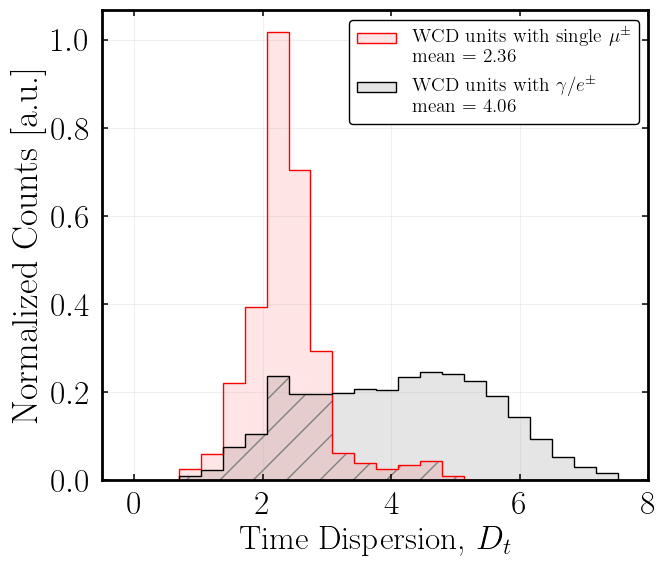

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


class OffsetHandler(HandlerBase):

    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        patch = Rectangle((0, 0), width, height, facecolor=orig_handle.get_facecolor(), edgecolor=orig_handle.get_edgecolor(), linewidth=orig_handle.get_linewidth())
        offset_transform = trans + mtransforms.Affine2D().translate(self.x_offset, self.y_offset)
        patch.set_transform(offset_transform)
        return [patch]


sm_dt = df_sm["D_t"].dropna().to_numpy()
eg_dt = df_eg["D_t"].dropna().to_numpy()

print("Numero di eventi single-muon =", len(sm_dt))
print("Numero di eventi gamma/e± =", len(eg_dt))

all_dt = np.concatenate((sm_dt, eg_dt))

bins = 20
range_hist = (np.percentile(all_dt, 0.5), np.percentile(all_dt, 99.5))

counts_sm, bin_edges = np.histogram(sm_dt, bins=bins, range=range_hist, density=True)
counts_eg, _ = np.histogram(eg_dt, bins=bins, range=range_hist, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

overlap = np.minimum(counts_sm, counts_eg)

sm_mean = np.mean(sm_dt)
sm_std = np.std(sm_dt)

eg_mean = np.mean(eg_dt)
eg_std = np.std(eg_dt)

ovl_dt = np.sum(overlap) * bin_width
tv_dt = 0.5 * np.sum(np.abs(counts_sm - counts_eg)) * bin_width

print(f"Single-muon mean = {sm_mean:.3f}")
print(f"Single-muon standard deviation = {sm_std:.3f}")
print(f"Gamma/e± mean = {eg_mean:.3f}")
print(f"Gamma/e± standard deviation = {eg_std:.3f}")
print(f"Overlap = {ovl_dt:.3f}")
print(f"Total variation distance = {tv_dt:.3f}")

plt.figure(figsize=(7, 6))

plt.hist(sm_dt, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="red", alpha=0.1)
plt.hist(sm_dt, density=True, bins=bins, range=range_hist, histtype="step", color="red", lw=1)

plt.hist(eg_dt, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="black", alpha=0.1)
plt.hist(eg_dt, density=True, bins=bins, range=range_hist, histtype="step", color="black", lw=1)

plt.bar(bin_centers, overlap, width=bin_width, color="none", edgecolor="gray", hatch="/", linewidth=0)

handles = [
    Rectangle((0, 0), 1, 1, facecolor=(1, 0, 0, 0.1), edgecolor=(1, 0, 0, 1), linewidth=1),
    Rectangle((0, 0), 1, 1, facecolor=(0, 0, 0, 0.1), edgecolor=(0, 0, 0, 1), linewidth=1)
]

labels = [
    r"WCD units with single $\mu^{\pm}$" + "\n" + f"mean = {sm_mean:.2f}",
    r"WCD units with $\gamma/e^{\pm}$" + "\n" + f"mean = {eg_mean:.2f}"
]

plt.xlim(-0.5,8)

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=24, length=4)
plt.minorticks_off()

plt.xlabel(r"Time Dispersion, $D_t$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)

plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

legend = plt.legend(handles=handles, labels=labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=11)}, edgecolor="black", handleheight=0.4, facecolor="white", framealpha=1.0, fontsize=14, loc="upper right")

legend.get_frame().set_linewidth(1)

plt.tight_layout()

plt.savefig(pictures_save_dir / "time_dispersion_Dt.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "time_dispersion_Dt.png", dpi=600, bbox_inches="tight")

plt.show()

Numero di eventi single-muon = 67014
Numero di eventi gamma/e± = 379497
Single-muon mean = 0.831
Single-muon standard deviation = 0.183
Gamma/e± mean = 0.531
Gamma/e± standard deviation = 0.290
Overlap = 0.526
Total variation distance = 0.474


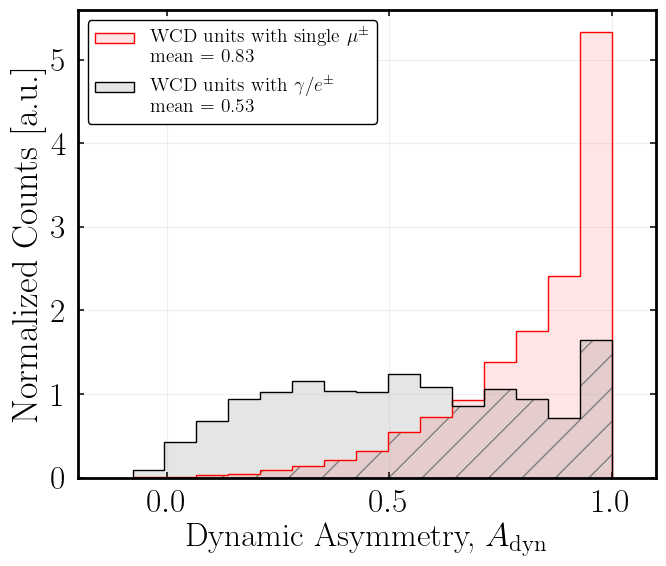

In [8]:
sm_adyn = df_sm["a_dyn"].dropna().to_numpy()
eg_adyn = df_eg["a_dyn"].dropna().to_numpy()

print("Numero di eventi single-muon =", len(sm_adyn))
print("Numero di eventi gamma/e± =", len(eg_adyn))

all_adyn = np.concatenate((sm_adyn, eg_adyn))

bins = 15
range_hist = (np.percentile(all_adyn, 0.5), np.percentile(all_adyn, 99.5))

counts_sm, bin_edges = np.histogram(sm_adyn, bins=bins, range=range_hist, density=True)
counts_eg, _ = np.histogram(eg_adyn, bins=bins, range=range_hist, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

overlap = np.minimum(counts_sm, counts_eg)

sm_mean = np.mean(sm_adyn)
sm_std = np.std(sm_adyn)

eg_mean = np.mean(eg_adyn)
eg_std = np.std(eg_adyn)

ovl_adyn = np.sum(overlap) * bin_width
tv_adyn = 0.5 * np.sum(np.abs(counts_sm - counts_eg)) * bin_width

print(f"Single-muon mean = {sm_mean:.3f}")
print(f"Single-muon standard deviation = {sm_std:.3f}")
print(f"Gamma/e± mean = {eg_mean:.3f}")
print(f"Gamma/e± standard deviation = {eg_std:.3f}")
print(f"Overlap = {ovl_adyn:.3f}")
print(f"Total variation distance = {tv_adyn:.3f}")

plt.figure(figsize=(7, 6))

plt.hist(sm_adyn, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="red", alpha=0.1)
plt.hist(sm_adyn, density=True, bins=bins, range=range_hist, histtype="step", color="red", lw=1)

plt.hist(eg_adyn, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="black", alpha=0.1)
plt.hist(eg_adyn, density=True, bins=bins, range=range_hist, histtype="step", color="black", lw=1)

plt.bar(bin_centers, overlap, width=bin_width, color="none", edgecolor="gray", hatch="/", linewidth=0)

handles = [
    Rectangle((0, 0), 1, 1, facecolor=(1, 0, 0, 0.1), edgecolor=(1, 0, 0, 1), linewidth=1),
    Rectangle((0, 0), 1, 1, facecolor=(0, 0, 0, 0.1), edgecolor=(0, 0, 0, 1), linewidth=1)
]

labels = [
    r"WCD units with single $\mu^{\pm}$" + "\n" + f"mean = {sm_mean:.2f}",
    r"WCD units with $\gamma/e^{\pm}$" + "\n" + f"mean = {eg_mean:.2f}"
]

plt.xlim(-0.2, 1.1)

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=24, length=4)
plt.minorticks_off()

plt.xlabel(r"Dynamic Asymmetry, $A_{\mathrm{dyn}}$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)

plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

legend = plt.legend(handles=handles, labels=labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=11)}, edgecolor="black", handleheight=0.4, facecolor="white", framealpha=1.0, fontsize=14, loc="upper left")

legend.get_frame().set_linewidth(1)

plt.tight_layout()


plt.savefig(pictures_save_dir / "Dynamic_Asymmetry_Adyn.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "Dynamic_Asymmetry_Adyn.png", dpi=600, bbox_inches="tight")

plt.show()

Numero di eventi single-muon = 67014
Numero di eventi gamma/e± = 379504
Single-muon median = 38.000
Gamma/e± median = 34.000
Overlap = 0.771
Total variation distance = 0.229


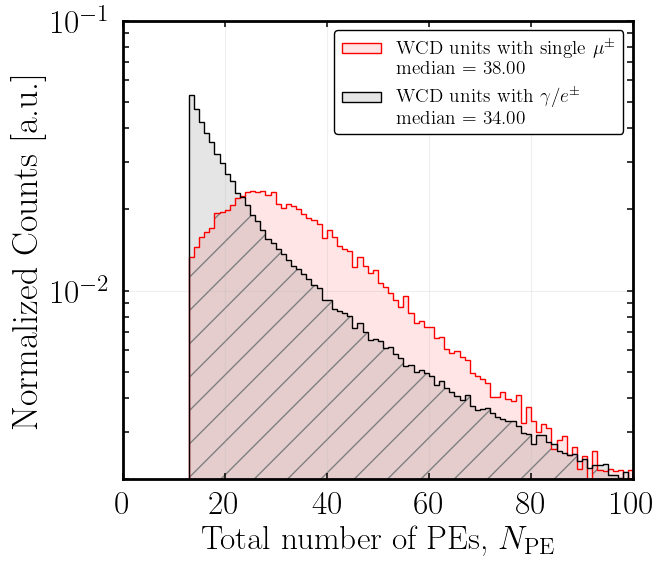

In [9]:
sm_total_pe = df_sm["total_pe"].dropna().to_numpy()
eg_total_pe = df_eg["total_pe"].dropna().to_numpy()

print("Numero di eventi single-muon =", len(sm_total_pe))
print("Numero di eventi gamma/e± =", len(eg_total_pe))

all_total_pe = np.concatenate((sm_total_pe, eg_total_pe))

bins = 300
range_hist = (0, 300)

counts_sm, bin_edges = np.histogram(sm_total_pe, bins=bins, range=range_hist, density=True)
counts_eg, _ = np.histogram(eg_total_pe, bins=bins, range=range_hist, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

overlap = np.minimum(counts_sm, counts_eg)

sm_median = np.median(sm_total_pe)
eg_median = np.median(eg_total_pe)

ovl_total_pe = np.sum(overlap) * bin_width
tv_total_pe = 0.5 * np.sum(np.abs(counts_sm - counts_eg)) * bin_width

print(f"Single-muon median = {sm_median:.3f}")
print(f"Gamma/e± median = {eg_median:.3f}")
print(f"Overlap = {ovl_total_pe:.3f}")
print(f"Total variation distance = {tv_total_pe:.3f}")

plt.figure(figsize=(7, 6))

plt.hist(sm_total_pe, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="red", alpha=0.1)
plt.hist(sm_total_pe, density=True, bins=bins, range=range_hist, histtype="step", color="red", lw=1)

plt.hist(eg_total_pe, density=True, bins=bins, range=range_hist, histtype="stepfilled", color="black", alpha=0.1)
plt.hist(eg_total_pe, density=True, bins=bins, range=range_hist, histtype="step", color="black", lw=1)

plt.bar(bin_centers, overlap, width=bin_width, color="none", edgecolor="gray", hatch="/", linewidth=0)

handles = [
    Rectangle((0, 0), 1, 1, facecolor=(1, 0, 0, 0.1), edgecolor=(1, 0, 0, 1), linewidth=1),
    Rectangle((0, 0), 1, 1, facecolor=(0, 0, 0, 0.1), edgecolor=(0, 0, 0, 1), linewidth=1)
]

labels = [
    r"WCD units with single $\mu^{\pm}$" + "\n" + f"median = {sm_median:.2f}",
    r"WCD units with $\gamma/e^{\pm}$" + "\n" + f"median = {eg_median:.2f}"
]

plt.xlim(0, 100)

plt.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=24, length=4)
plt.minorticks_off()

plt.xlabel(r"Total number of PEs, $N_{\mathrm{PE}}$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)

plt.yscale("log")
plt.ylim(2e-3, 1e-1)

plt.grid(True, alpha=0.2)

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

legend = plt.legend(handles=handles, labels=labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=11)}, edgecolor="black", handleheight=0.4, facecolor="white", framealpha=1.0, fontsize=14, loc="upper right")

legend.get_frame().set_linewidth(1)

plt.tight_layout()
plt.show()

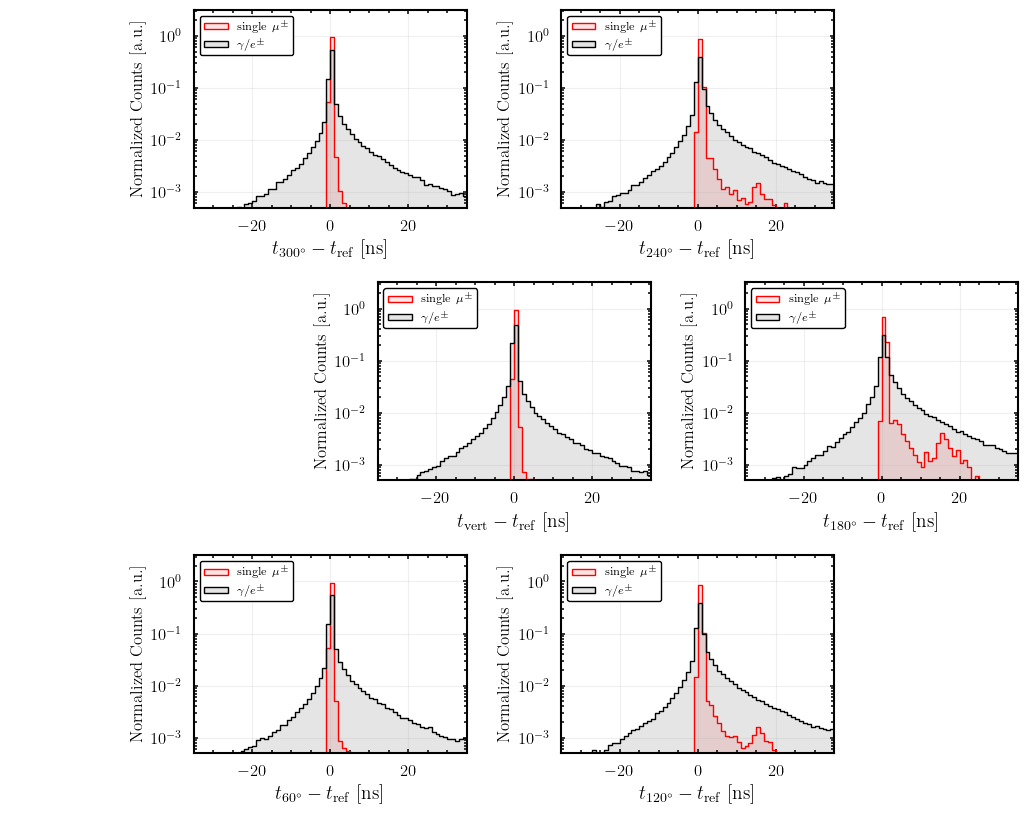

In [10]:
tref_data_sm = {
    "0": df_sm["t_ref0"],
    "60": df_sm["t_ref60"],
    "120": df_sm["t_ref120"],
    "180": df_sm["t_ref180"],
    "240": df_sm["t_ref240"],
    "300": df_sm["t_ref300"]
}

tref_data_eg = {
    "0": df_eg["t_ref0"],
    "60": df_eg["t_ref60"],
    "120": df_eg["t_ref120"],
    "180": df_eg["t_ref180"],
    "240": df_eg["t_ref240"],
    "300": df_eg["t_ref300"]
}

fig = plt.figure(figsize=(10.5, 9))

w = 0.26
h = 0.22
cx = 0.43
cy = 0.50
r = 0.35

pos = {
    "0": [cx - w / 2, cy - h / 2, w, h],
    "ref": [cx - r - w / 2, cy - h / 2, w, h],
    "60": [cx + r * np.cos(np.deg2rad(240)) - w / 2, cy + r * np.sin(np.deg2rad(240)) - h / 2, w, h],
    "120": [cx + r * np.cos(np.deg2rad(300)) - w / 2, cy + r * np.sin(np.deg2rad(300)) - h / 2, w, h],
    "180": [cx + r - w / 2, cy - h / 2, w, h],
    "240": [cx + r * np.cos(np.deg2rad(60)) - w / 2, cy + r * np.sin(np.deg2rad(60)) - h / 2, w, h],
    "300": [cx + r * np.cos(np.deg2rad(120)) - w / 2, cy + r * np.sin(np.deg2rad(120)) - h / 2, w, h]
}

axes_keys = ["ref", "0", "60", "120", "180", "240", "300"]
axes_list = {}

x_min = -35
x_max = 35
bin_width = 1.0
bin_edges = np.arange(x_min, x_max + bin_width, bin_width)

handles = [
    Rectangle((0, 0), 1, 1, facecolor=(1, 0, 0, 0.1), edgecolor=(1, 0, 0, 1), linewidth=1),
    Rectangle((0, 0), 1, 1, facecolor=(0, 0, 0, 0.1), edgecolor=(0, 0, 0, 1), linewidth=1)
]

labels = [
    r"single $\mu^{\pm}$",
    r"$\gamma/e^{\pm}$"
]

for key in axes_keys:

    a = fig.add_axes(pos[key])
    axes_list[key] = a

    if key == "ref":
        a.set_axis_off()
        continue

    tref_sm = tref_data_sm[key].dropna().to_numpy()
    tref_eg = tref_data_eg[key].dropna().to_numpy()

    counts_sm, _ = np.histogram(tref_sm, bins=bin_edges, density=True)
    counts_eg, _ = np.histogram(tref_eg, bins=bin_edges, density=True)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    step_x = np.r_[bin_edges[0], np.repeat(bin_edges, 2)[1:-1], bin_edges[-1]]
    step_y_sm = np.r_[0, np.repeat(counts_sm, 2), 0]
    step_y_eg = np.r_[0, np.repeat(counts_eg, 2), 0]

    a.bar(bin_centers, counts_sm, width=bin_width, color="red", alpha=0.1, align="center")
    a.bar(bin_centers, counts_eg, width=bin_width, color="black", alpha=0.1, align="center")

    a.step(step_x, step_y_sm, color="red", linewidth=1)
    a.step(step_x, step_y_eg, color="black", linewidth=1)

    a.set_yscale("log")
    a.set_xlim(x_min, x_max)
    a.set_ylim(5e-4, 3.2)

    if key == "0":
        channel_label = r"\mathrm{vert}"
    else:
        channel_label = rf"{key}^\circ"

    a.set_xlabel(rf"$t_{{{channel_label}}}-t_{{\mathrm{{ref}}}}\;[\mathrm{{ns}}]$", fontsize=14)
    a.set_ylabel("Normalized Counts [a.u.]", fontsize=12)

    for spine in a.spines.values():
        spine.set_linewidth(1.5)

    a.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    a.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
    a.yaxis.set_minor_formatter(NullFormatter())

    a.tick_params(axis="both", which="major", direction="in", top=True, right=True, labelsize=12, length=3.0)
    a.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=2.5)

    a.grid(True, alpha=0.2)

    legend = a.legend(handles=handles, labels=labels, handler_map={Rectangle: OffsetHandler(x_offset=0, y_offset=0.5)}, frameon=True, facecolor="white", framealpha=1.0, fontsize=8.5, loc="upper left", handleheight=0.4, edgecolor="black")
    legend.get_frame().set_linewidth(1)

plt.show()